# Exploration Notebook

**READ.ME**

This file helps you explore the functions of Brightway 2.5 in an intuitive way. So far, we have linked a background database with a simple foreground model in the previous sections of this repository. It is not a tutorial to go through, but a collection of usable code which you can adapt for your own projects. The goal is to make this Brightway 2.5 repository easy and reusable to use for your own projects.

## ⚙️ Step 1: Load Your Project

After ensuring all necessary packages are installed, you call the same project where you have installed and imported your databases. This happens through `bd.projects.set_current(Config.PROJECT_NAME)`

In [ ]:
import importlib
import functions.utils as utils

importlib.reload(utils)
from functions.utils import Config

In [ ]:
# This should be extended or reduced depending on the suggested functionalities

# basic imports from brightway
import bw2analyzer as ba
import bw2calc as bc
import bw2data as bd
import bw2io as bi
import bw2analyzer as bwa
from bw2data import methods
from bw2io import create_default_biosphere3
from functions.utils import Config

# other relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [ ]:
# define a project where we install the databases and work in this script
bd.projects.set_current(Config.PROJECT_NAME)

In [61]:
# Apply the default plotting theme for this notebook.
from functions.fun_visualisation import apply_20lca_theme, plot_contribution_bar, plot_stacked

apply_20lca_theme()

## ⚙️ Step 2: Database overview

This section provides an overview of the background and foreground databases stored in the Brightway project.

In [ ]:
bd.databases

In [ ]:
bd.projects.current

In [ ]:
ei_clca = bd.Database('ecoinvent-3.12-consequential')
ei_bio = bd.Database('ecoinvent-3.12-biosphere')
bafu2026 = bd.Database('bafu2026')
bonsai = bd.Database('BONSAI_V2.1.6')
bw_template = bd.Database('brightway_project_template')

## 🔍 Step 3: Searching the Database

Use the following `database.search('')` function to search for entries in your database

In [ ]:
# search for activities in the database
ei_clca.search('electricity')

In [ ]:
bw_template.search('ceramics')

## 🧾 Step 4: Select a Process & Check Inventory

`define_name = database.get(name='', location='', unit='')` assigns the object "define_name" to the entry in the database that matches the search criteria.
    
You can directly export the inventory of the defined process to an Excel overview through `bi.export.excel.write_lci_excel(database.name, objs=[define_name], dirpath=Path.cwd())`.

In [ ]:
# define a process and store in a object in the project
porcelain_ceramics = bw_template.get(name = 'production of porcelain ceramics', location = "RER", unit = 'kilogram')
sanitary_ceramics = ei_clca.get(name = 'sanitary ceramics production', location = "CH", unit = 'kilogram')

In [ ]:
# export the LCI to Microsoft Excel in an overview format
bi.export.excel.write_lci_excel(bw_template.name, objs=[porcelain_ceramics], dirpath=Path.cwd())

In [ ]:
list(porcelain_ceramics.production())


In [ ]:
list(porcelain_ceramics.technosphere())


In [ ]:
list(porcelain_ceramics.biosphere())


In [ ]:
list(porcelain_ceramics.consumers())


In [ ]:
# (1) this is a way to print all exchanges of a process, there are multiple ways to extract this information
list(porcelain_ceramics.edges())


In [ ]:
# (2) this is an other way to print all exchanges of a process
exchanges = sorted(porcelain_ceramics.exchanges(), key=lambda exc: exc['amount'], reverse=True)
for exc in exchanges:
    print(exc)

In [ ]:
# (3) Alternative way to display all exchanges with the technosphere
list(porcelain_ceramics.technosphere())

In [ ]:
# how to check the activity type of a process
check_activity_type = print(sanitary_ceramics["activity type"])

## 🌿 Step 4: Impact Assessment Methods

To calculate the Life Cycle Impacts the back- and foreground need to be linked to an assessment method. There is a large number of available methods that are pre-installed together with the ecoinvent biosphere flows in the 01_bw25_ecoinvent_importer script.

In [ ]:
# here we will analyse the set of methods that are available as part of the background
list(bd.methods)[:5]

In [ ]:
# printing all methods that contain a specific keyword, e.g. "climate change"
climate_methods = [m for m in bd.methods if any("global warming potential" in str(part).lower() for part in m)]
for method in climate_methods:
    print(method)

In [ ]:
# selecting the impact assessment methods that we want to use in our analysis
lcia_gwp100 = ('ecoinvent-3.12', 'EF v3.1', 'climate change', 'global warming potential (GWP100)')

## 📈 5. LCIA: Overview

This section shows how LCA results can be calculated quickly and be displayed as final score, process- and elementary flow based.

In [28]:
# Quick LCIA calculation
porcelain_ceramics_lca = porcelain_ceramics.lca(lcia_gwp100)
porcelain_ceramics_lca.score

0.6749479642849595

In [29]:
sanitary_ceramics_lca = sanitary_ceramics.lca(lcia_gwp100)
sanitary_ceramics_lca.score

3.08873074900671

In [30]:
# Elementary flows contribution analysis as summary table
porcelain_ceramics_lca.to_dataframe().pivot_table(index='row_name',values='amount',aggfunc='sum')

,amount
row_name,
"Carbon dioxide, fossil",0.524631
Dinitrogen monoxide,0.001083
"Methane, fossil",0.099280


In [31]:
characterized_inventory = porcelain_ceramics_lca.to_dataframe()

## 📊 6. LCIA: Contribution analysis

There are different ways to analyse the contribution analysis in Brightway 2.5. Two ways are displayed below. The max_level and cutoff can be adjusted based on the level of detail you want from the analysis.

In [32]:
# One option to do a contribution analysis is to use the recursive calculation method
bwa.print_recursive_calculation(porcelain_ceramics,
lcia_method=lcia_gwp100,max_level=1,cutoff=0.005)

Fraction of score | Absolute score | Amount | Activity
0001 | 0.6749 |     1 | 'production of porcelain ceramics' (kilogram, RER, None)
  0.213 | 0.1439 | 0.5775 | 'market for kaolin' (kilogram, GLO, None)
  0.0219 | 0.01481 | 0.275 | 'market for feldspar' (kilogram, GLO, None)
  0.017 | 0.01148 | 0.2475 | 'market for silica sand' (kilogram, GLO, None)
  0.352 | 0.2375 | 1.028 | 'market group for electricity, high voltage' (kilowatt hour, RER, None)
  0.35 | 0.2363 | 0.4507 | 'market group for natural gas, high pressure' (cubic meter, Europe without Switzerland, None)
  0.0459 | 0.03096 | 1.25e-10 | 'packaging glass factory construction' (unit, RER, None)


In [33]:
# One option to do a contribution analysis is to use the recursive calculation method
bwa.print_recursive_calculation(sanitary_ceramics,
lcia_method=lcia_gwp100,max_level=1,cutoff=0.005)

Fraction of score | Absolute score | Amount | Activity
0001 | 3.089 |     1 | 'sanitary ceramics production' (kilogram, CH, None)
  0.0308 | 0.09502 | 4e-09 | 'ceramic factory construction' (unit, CH, None)
  0.0582 | 0.1798 | 0.878 | 'market for electricity, medium voltage' (kilowatt hour, CH, None)
  0.00661 | 0.02041 | 0.379 | 'market for feldspar' (kilogram, GLO, None)
  0.851 | 2.629 | 22.89 | 'market for heat, district or industrial, natural gas' (megajoule, CH, None)
  0.0358 | 0.1106 | 0.444 | 'market for kaolin' (kilogram, GLO, None)
  0.00572 | 0.01766 | 0.125 | 'market for stucco' (kilogram, GLO, None)


In [34]:
# Another option is to use the recursive calculation to an object, which returns a DataFrame
porcelain_ceramics_ca = bwa.utils.recursive_calculation_to_object(porcelain_ceramics,
                                          lcia_method=lcia_gwp100,
                                          max_level=1,
                                          cutoff=0.005,
                                          as_dataframe=True,
                                          )
porcelain_ceramics_ca

,label,parent,score,fraction,amount,name,key
0,root,NaN,0.674948,1.000000,1.000000e+00,production of porcelain ceramics,"(brightway_project_template, 18cf9c1477062c6c3..."
1,root_a,root,0.143875,0.213165,5.775000e-01,market for kaolin,"(ecoinvent-3.12-consequential, 1439cf096908796..."
2,root_b,root,0.014809,0.021941,2.750000e-01,market for feldspar,"(ecoinvent-3.12-consequential, 38b779a9752caf3..."
3,root_c,root,0.011482,0.017011,2.475000e-01,market for silica sand,"(ecoinvent-3.12-consequential, 42fbf9819e03152..."
4,root_d,root,0.237512,0.351897,1.027700e+00,"market group for electricity, high voltage","(ecoinvent-3.12-consequential, d2b2433d24c54e8..."
5,root_e,root,0.236306,0.350110,4.506667e-01,"market group for natural gas, high pressure","(ecoinvent-3.12-consequential, b575f5bf391b074..."
6,root_f,root,0.030963,0.045874,1.250000e-10,packaging glass factory construction,"(ecoinvent-3.12-consequential, 85bab1c73cbd732..."


In [35]:
# Another option is to use the recursive calculation to an object, which returns a DataFrame
sanitary_ceramics_ca = bwa.utils.recursive_calculation_to_object(sanitary_ceramics,
                                          lcia_method=lcia_gwp100,
                                          max_level=1,
                                          cutoff=0.005,
                                          as_dataframe=True,
                                          )
sanitary_ceramics_ca

,label,parent,score,fraction,amount,name,key
0,root,NaN,3.088731,1.000000,1.000000e+00,sanitary ceramics production,"(ecoinvent-3.12-consequential, 865d5e249bfa376..."
1,root_b,root,0.095020,0.030763,4.000000e-09,ceramic factory construction,"(ecoinvent-3.12-consequential, 69852bbafe615ba..."
2,root_e,root,0.179841,0.058225,8.780000e-01,"market for electricity, medium voltage","(ecoinvent-3.12-consequential, 045521b5763d77d..."
3,root_f,root,0.020410,0.006608,3.790000e-01,market for feldspar,"(ecoinvent-3.12-consequential, 38b779a9752caf3..."
4,root_h,root,2.629249,0.851239,2.289500e+01,"market for heat, district or industrial, natur...","(ecoinvent-3.12-consequential, 2fd188948680f30..."
5,root_j,root,0.110616,0.035813,4.440000e-01,market for kaolin,"(ecoinvent-3.12-consequential, 1439cf096908796..."
6,root_o,root,0.017659,0.005717,1.250000e-01,market for stucco,"(ecoinvent-3.12-consequential, 631a17914a1f2ba..."


## 🗂️ 7. LCIA: Characterized inventories

This section shows how to calculate LCA results and display the uncharacterized and characterized inventories with selected flow and process information. It also shows how to inspect the available metadata columns for further grouping and analysis.

In [36]:
porcelain_ceramics_lca = porcelain_ceramics.lca(lcia_gwp100)

In [37]:
columns = [
    'amount', 'row_database', 'row_name', 'row_categories',
    'col_database', 'col_name', 'col_unit', 'col_reference_product'
]

In [38]:
inventory = porcelain_ceramics_lca.to_dataframe(
    matrix_label='inventory', cutoff=0.005, cutoff_mode='fraction'
)
inventory[columns].head(20)

,amount,row_database,row_name,row_categories,col_database,col_name,col_unit,col_reference_product
0,54.924301,ecoinvent-3.12-biosphere,Radon-222,"air::low population density, long-term",ecoinvent-3.12-consequential,"treatment of tailing, from uranium milling",cubic meter,"tailing, from uranium milling"
1,9.563735,ecoinvent-3.12-biosphere,"Noble gases, radioactive, unspecified",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"treatment of spent nuclear fuel, reprocessing",kilogram,spent nuclear fuel
2,1.166249,ecoinvent-3.12-biosphere,Non-hazardous waste disposed,inventory indicator::waste,ecoinvent-3.12-consequential,"treatment of spoil from lignite mining, in sur...",kilogram,spoil from lignite mining
3,1.042851,ecoinvent-3.12-biosphere,"Energy, gross calorific value, in biomass",natural resource::biotic,ecoinvent-3.12-consequential,"hardwood forestry, birch, sustainable forest m...",kilogram,"wood chips, green, measured as dry mass"
4,0.946510,ecoinvent-3.12-biosphere,Water,water,ecoinvent-3.12-consequential,"electricity production, hydro, run-of-river",kilowatt hour,"electricity, high voltage"
5,0.946510,ecoinvent-3.12-biosphere,"Water, turbine use, unspecified natural origin",natural resource::in water,ecoinvent-3.12-consequential,"electricity production, hydro, run-of-river",kilowatt hour,"electricity, high voltage"
6,0.639418,ecoinvent-3.12-biosphere,Radon-222,air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"uranium mine operation, underground",kilogram,"uranium ore, as U"
7,0.603606,ecoinvent-3.12-biosphere,Radon-222,air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"uranium mine operation, underground",kilogram,"uranium ore, as U"
8,0.538090,ecoinvent-3.12-biosphere,"Water, turbine use, unspecified natural origin",natural resource::in water,ecoinvent-3.12-consequential,"electricity production, hydro, run-of-river",kilowatt hour,"electricity, high voltage"
9,0.538090,ecoinvent-3.12-biosphere,Water,water,ecoinvent-3.12-consequential,"electricity production, hydro, run-of-river",kilowatt hour,"electricity, high voltage"


In [39]:
characterized = porcelain_ceramics_lca.to_dataframe(
    matrix_label='characterized_inventory', cutoff=0.005, cutoff_mode='fraction'
)
characterized[columns].head(20)

,amount,row_database,row_name,row_categories,col_database,col_name,col_unit,col_reference_product
0,0.064310,ecoinvent-3.12-biosphere,"Methane, fossil",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,natural gas venting from petroleum/natural gas...,cubic meter,"natural gas, vented"
1,0.042091,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"electricity production, lignite",kilowatt hour,"electricity, high voltage"
2,0.038280,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"sweet gas, burned in gas turbine",megajoule,"sweet gas, burned in gas turbine"
3,0.033069,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"electricity production, natural gas, combined ...",kilowatt hour,"electricity, high voltage"
4,0.029139,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"electricity production, natural gas, combined ...",kilowatt hour,"electricity, high voltage"
5,0.019093,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"heat and power co-generation, lignite",megajoule,"heat, district or industrial, other than natur..."
6,0.019073,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::urban air close to ground,ecoinvent-3.12-consequential,"heat and power co-generation, natural gas, 200...",megajoule,"heat, district or industrial, natural gas"
7,0.017707,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"treatment of waste natural gas, sweet, burned ...",megajoule,"waste natural gas, sweet"
8,0.017562,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::urban air close to ground,ecoinvent-3.12-consequential,"natural gas, burned in gas turbine",megajoule,"natural gas, burned in gas turbine"
9,0.014452,ecoinvent-3.12-biosphere,"Carbon dioxide, fossil",air::non-urban air or from high stacks,ecoinvent-3.12-consequential,"electricity production, lignite",kilowatt hour,"electricity, high voltage"


In [40]:
# Inspect available metadata columns before choosing a grouping.
characterized.columns.tolist()


['row_index',
 'col_index',
 'amount',
 'row_id',
 'col_id',
 'row_database',
 'row_code',
 'row_name',
 'row_location',
 'row_unit',
 'row_type',
 'row_categories',
 'row_product',
 'col_database',
 'col_code',
 'col_name',
 'col_location',
 'col_unit',
 'col_type',
 'col_reference_product']

### 7a. Contribution by elementary flow

In [41]:
flow_contributions = characterized.groupby(
    ['row_name'], dropna=False
)['amount'].sum()
flow_contributions = flow_contributions.loc[
    flow_contributions.abs().sort_values(ascending=False).index
]
flow_contributions.head(15)

row_name
Carbon dioxide, fossil    0.399635
Methane, fossil           0.071906
Name: amount, dtype: float64

### 7b. Direct contribution by process

In [42]:
process_contributions = characterized.groupby(
    ['col_name', 'col_location'], dropna=False
)['amount'].sum()
process_contributions = process_contributions.loc[
    process_contributions.abs().sort_values(ascending=False).index
]
process_contributions.head(15)


col_name                                                                                 col_location
natural gas venting from petroleum/natural gas production                                GLO             0.064310
electricity production, lignite                                                          UA              0.042091
sweet gas, burned in gas turbine                                                         GLO             0.038280
electricity production, natural gas, combined cycle power plant                          UA              0.033069
                                                                                         RoW             0.029139
heat and power co-generation, lignite                                                    RoW             0.019093
heat and power co-generation, natural gas, 200kW electrical, lean burn                   RoW             0.019073
treatment of waste natural gas, sweet, burned in production flare                        GLO        

### 7c. Contribution by process location

This is the recorded location of the emitting process. It is not automatically the location of environmental damage, the consumer, or the origin of a raw material. Regional labels such as GLO and RoW remain part of the result.


In [43]:
location_contributions = characterized.groupby('col_location', dropna=False)['amount'].sum()
location_contributions = location_contributions.loc[
    location_contributions.abs().sort_values(ascending=False).index
]
location_contributions


col_location
GLO        0.141740
RoW        0.103079
UA         0.075160
RU         0.041211
PL         0.017597
US         0.017562
IT         0.014367
RER        0.012251
RS         0.008222
BE         0.006358
NL         0.006158
DE         0.005761
QA         0.005267
US-SERC    0.004877
DZ         0.004445
BA         0.003823
SE         0.003663
Name: amount, dtype: float64

### 7d. Native matrix totals and balance check

These direct matrix operations correspond to the aggregation used in Elea-and-Lili's analysis utilities. They do not require copying the repository's custom functions. `axis=1` sums across processes; `axis=0` sums across flows. Matrix index-to-node mappings are provided by Brightway.


In [44]:
flow_totals = np.asarray(porcelain_ceramics_lca.characterized_inventory.sum(axis=1)).ravel()
process_totals = np.asarray(porcelain_ceramics_lca.characterized_inventory.sum(axis=0)).ravel()

pd.Series({
    'LCIA score': porcelain_ceramics_lca.score,
    'Sum of flow totals': flow_totals.sum(),
    'Sum of process totals': process_totals.sum(),
    'Sum of dataframe entries': characterized['amount'].sum(),
})


LCIA score                  0.674948
Sum of flow totals          0.674948
Sum of process totals       0.674948
Sum of dataframe entries    0.471541
dtype: float64

In [45]:
# Example: find the Brightway node for the largest absolute direct process contribution.
largest_process_index = int(np.abs(process_totals).argmax())
process_id = porcelain_ceramics_lca.dicts.activity.reversed[largest_process_index]
bd.get_node(id=process_id)


'natural gas venting from petroleum/natural gas production' (cubic meter, GLO, None)

### 7e. Display the largest contributors

**From:** the native Brightway output → pandas/Seaborn/Matplotlib workflow in Toolbox and the template. The following uses pandas' plotting interface directly. It is a top-15 display, not the full accounting total; omitted contributions remain in `process_contributions`.


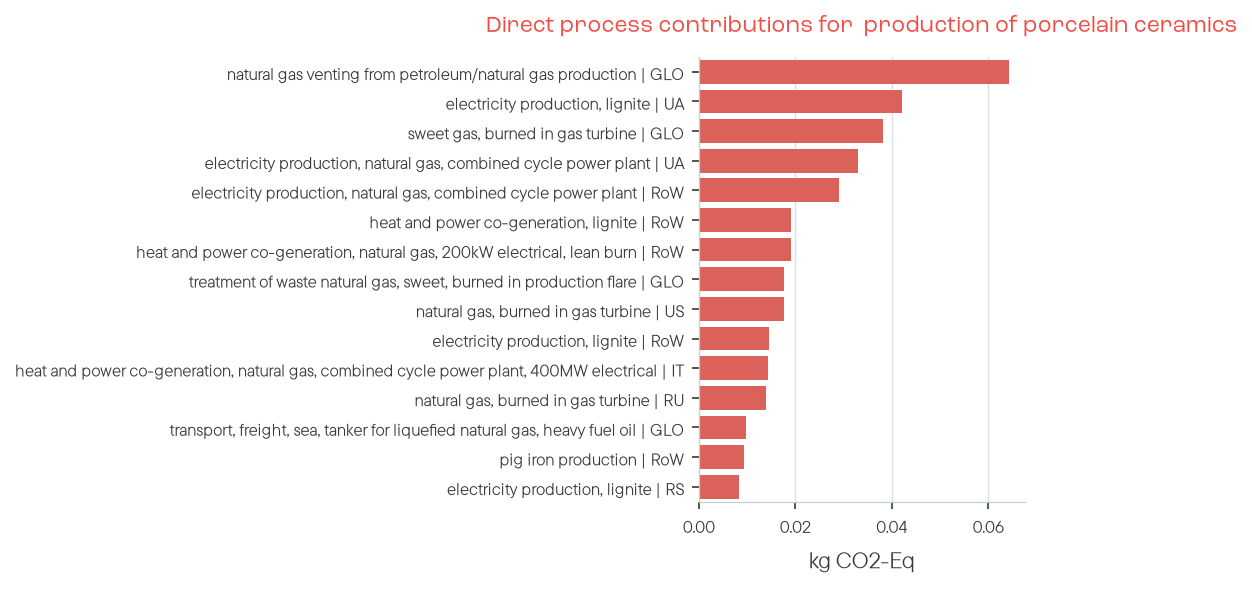

In [46]:
from functions.fun_visualisation import plot_bar

method_unit = bd.Method(lcia_gwp100).metadata.get('unit', 'LCIA units')

top_processes = process_contributions.head(15)
plot_data = top_processes.rename('amount').to_frame().reset_index(drop=True)
plot_data['process'] = [
    ' | '.join(map(str, label)) if isinstance(label, tuple) else str(label)
    for label in top_processes.index
]

fig, ax = plot_bar(
    plot_data,
    x='amount',
    y='process',
    horizontal=True,
    title=f"Direct process contributions for \n{porcelain_ceramics['name']}",    xlabel=f'{method_unit}',
    figsize=(7, 4),
    show=False,
)

ax.title.set_fontsize(11)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

## 🎨 8. Plot Contribution analysis graphs

In [47]:
# Filter out the parent processes that are not relevant for the contribution analysis
porcelain_ceramics_ca = porcelain_ceramics_ca.dropna(subset='parent')
sanitary_ceramics_ca = sanitary_ceramics_ca.dropna(subset='parent')

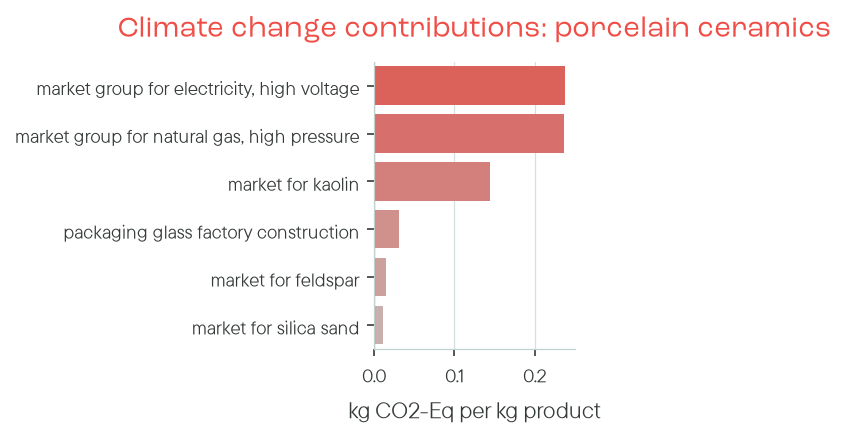

In [62]:
impact_unit = bd.methods[lcia_gwp100]["unit"]

fig, ax = plot_contribution_bar(
    porcelain_ceramics_ca,
    title="Climate change contributions: porcelain ceramics",
    unit=f"{impact_unit} per kg product",
    top_n=10,
    figsize=(4, 3),
)

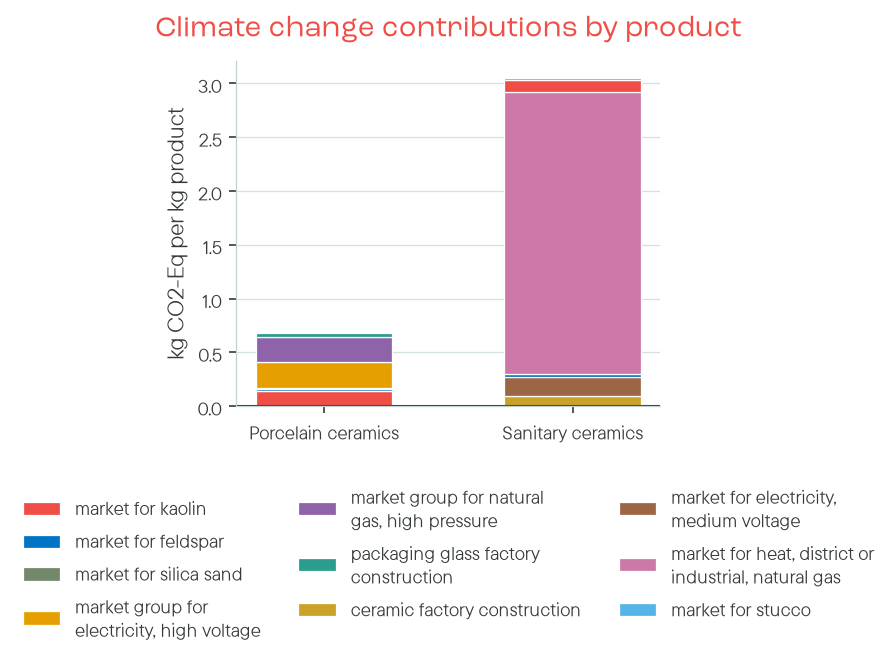

In [64]:
fig_comparison, ax, color_map = plot_stacked(
    porcelain_ceramics_ca,
    sanitary_ceramics_ca,
    labels=["Porcelain ceramics", "Sanitary ceramics"],
    title="Climate change contributions by product",
    unit=f"{impact_unit} per kg product",
    figsize=(5, 6),
)